# Assignment 8 — Robustness Analysis

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  


---

## Learning Outcomes

After completing this assignment you will be able to:

1. Re-evaluate a set of Pareto-optimal policies across an ensemble of climate
   scenarios.

2. Compute and interpret **satisficing scores** — the fraction of scenarios in
   which a policy meets an acceptable threshold on all objectives simultaneously.

3. Compute and interpret **minimax regret** — the worst-case loss a policy
   incurs relative to the best achievable outcome in each scenario.

---

## Assignment Overview

This assignment re-evaluates your Pareto-optimal policies by re-running JUSTICE across multiple climate scenarios (FAIR ensemble members) and applying two complementary robustness metrics:

- **Satisficing** — does the policy meet an acceptable threshold on every objective, across enough scenarios?
- **Minimax regret** — which policy has the smallest worst-case loss relative to what was achievable?

**What you will do**

- Run `run_reeval.py` to evaluate every policy under multiple climate scenarios
- Apply satisficing analysis — choose thresholds, compute scores, and visualise
- Apply minimax regret — compute worst-case performance 

**What you will need**

- Your **reference set** from Assignment 6 (the Pareto-optimal solutions)
- Your **config file** the one you used to run the optimization or optimizations

**What you will produce**

- A heatmap showing which objectives are hardest to satisfy
- A maximum regret ranking of all policies
- A CDF plot of worst-case regret across the Pareto front
- Your recommended solution based on the analysis

> **Scope note:** This is a simplified robustness analysis. A full robustness
> analysis would test policy performance across uncertainty in many parameters
> simultaneously, you can think of all the model assumptions, economic inputs, damage functions, and
> more. Here we vary only the climate uncertainty (FAIR ensemble members),
> holding everything else fixed. This is a meaningful first step, but keep in
> mind that the robustness scores you compute reflect climate uncertainty only,
> not the full uncertainty space the model operates in.

___

## Setup — Imports, paths, and model constants

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")

RESULTS_ROOT = os.path.join(_NOTEBOOK_DIR, "results")
_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

# ── Objective names ───────────────────────────────────────────────────────────
# Optimisation files use fraction_above_threshold.
# Re-evaluation files may use years_above_temperature_threshold.
OBJECTIVE_COLS = [
    "welfare",
    "years_above_temperature_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

OBJECTIVE_LABELS = {
    "welfare": "Welfare",
    "years_above_temperature_threshold": "Years above threshold",
    "welfare_loss_damage": "Welfare loss from damage",
    "welfare_loss_abatement": "Welfare loss from abatement",
}

# Lower is better for all four in the re-evaluation outcome table.
MINIMIZE_COLS = OBJECTIVE_COLS

print("Notebook dir :", _NOTEBOOK_DIR)
print("Results root :", RESULTS_ROOT)
print("Results exist:", os.path.exists(RESULTS_ROOT))
print("Plots dir    :", _PLOTS_DIR)
print("Assignment 8 setup OK")

Notebook dir : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased
Results root : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results
Results exist: True
Plots dir    : c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots
Assignment 8 setup OK


In [4]:
# ── Check for re-evaluation script ────────────────────────────────────────────

possible_scripts = [
    os.path.join(_NOTEBOOK_DIR, "run_reeval.py"),
    r"C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py",
    r"C:\Users\jobm3\Downloads\epa141a\assignments_ema\run_reeval.py",
]

for p in possible_scripts:
    print(p, "→", os.path.exists(p))

c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval.py → True
C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py → True
C:\Users\jobm3\Downloads\epa141a\assignments_ema\run_reeval.py → True


In [6]:
from pathlib import Path

reeval_path = Path(r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval.py")
backup_path = reeval_path.with_name("run_reeval_original_backup.py")

if not reeval_path.exists():
    raise FileNotFoundError(f"Cannot find {reeval_path}")

# Make backup once
if not backup_path.exists():
    backup_path.write_text(reeval_path.read_text(encoding="utf-8"), encoding="utf-8")
    print(f"Backup created: {backup_path}")
else:
    print(f"Backup already exists: {backup_path}")

text = reeval_path.read_text(encoding="utf-8")

old_block = '''try:
    _SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _SCRIPT_DIR = os.path.abspath(".")

_JUSTICE_ROOT = os.path.normpath(os.path.join(_SCRIPT_DIR, "../JUSTICE-main"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)
'''

new_block = '''try:
    _SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _SCRIPT_DIR = os.path.abspath(".")

# Patched for working from Final_Assignment_ModelBased.
# The actual JUSTICE model remains in the class repo.
_JUSTICE_ROOT = r"C:\\Users\\jobm3\\Downloads\\epa141a\\JUSTICE-main"

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)
'''

if old_block in text:
    text = text.replace(old_block, new_block)
else:
    # Fallback: replace only the JUSTICE_ROOT assignment line
    text = text.replace(
        '_JUSTICE_ROOT = os.path.normpath(os.path.join(_SCRIPT_DIR, "../JUSTICE-main"))',
        r'_JUSTICE_ROOT = r"C:\Users\jobm3\Downloads\epa141a\JUSTICE-main"'
    )

reeval_path.write_text(text, encoding="utf-8")

print("Patched run_reeval.py to use:")
print(r"C:\Users\jobm3\Downloads\epa141a\JUSTICE-main")

Backup created: C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_original_backup.py
Patched run_reeval.py to use:
C:\Users\jobm3\Downloads\epa141a\JUSTICE-main


In [7]:
import os

justice_root = r"C:\Users\jobm3\Downloads\epa141a\JUSTICE-main"

print("JUSTICE root exists:", os.path.exists(justice_root))
print("run_reeval exists:", os.path.exists(r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval.py"))

JUSTICE root exists: True
run_reeval exists: True


In [9]:
from pathlib import Path
import re

reeval_path = Path(r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval.py")

text = reeval_path.read_text(encoding="utf-8")

# Replace any existing _CONFIG_DIR assignment with the correct absolute class-repo config path.
text_new = re.sub(
    r'_CONFIG_DIR\s*=\s*.*',
    r'_CONFIG_DIR = r"C:\Users\jobm3\Downloads\epa141a\config"',
    text,
    count=1
)

if text_new == text:
    print("Warning: did not find an _CONFIG_DIR assignment to replace.")
else:
    reeval_path.write_text(text_new, encoding="utf-8")
    print("Patched _CONFIG_DIR to:")
    print(r"C:\Users\jobm3\Downloads\epa141a\config")

PatternError: bad escape \U at position 18

In [10]:
import subprocess
import sys
import os

# Use the original run_reeval.py from the class repo
script_path = r"C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py"

cmd = [sys.executable, script_path, "--help"]

print("Command:")
print(" ".join(cmd))

result = subprocess.run(
    cmd,
    cwd=r"C:\Users\jobm3\Downloads\epa141a\model_answers_ema",
    capture_output=True,
    text=True
)

print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)

print("Exit code:", result.returncode)

Command:
c:\Users\jobm3\anaconda3\envs\epa141a\python.exe C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py --help
STDOUT:
usage: run_reeval.py [-h] [--n_scenarios N_SCENARIOS] [--n_cores N_CORES]

Parallel robustness re-evaluation for JUSTICE.

options:
  -h, --help            show this help message and exit
  --n_scenarios N_SCENARIOS
                        Number of FAIR ensemble members to use (default: 1000
                        = full ensemble)
  --n_cores N_CORES     Number of CPU cores (default: all available)

STDERR:

Exit code: 0


In [11]:
from pathlib import Path

script_path = Path(r"C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py")

text = script_path.read_text(encoding="utf-8")

keywords = [
    "RESULTS",
    "results",
    "POLICY",
    "policy",
    "pareto",
    "csv",
    "output",
    "to_csv",
    "read_csv",
    "n_scenarios",
    "n_cores",
    "welfare",
    "UTILITARIAN",
    "PRIORITARIAN",
]

print("Important lines in run_reeval.py:")
print("=" * 80)

for i, line in enumerate(text.splitlines(), start=1):
    if any(k in line for k in keywords):
        print(f"{i:4d}: {line}")

Important lines in run_reeval.py:
   4: Runs the full policy × scenario experiment using EMA Workbench's
  20:   .venv/bin/python model_answers_ema/run_reeval.py --n_scenarios 200 --n_cores 4
  23:   .venv/bin/python model_answers_ema/run_reeval.py --n_scenarios 5 --n_cores 2
  25: Runtime estimate (sequential time ÷ n_cores)
  43: RESULTS_ROOT  = os.path.join(_SCRIPT_DIR, "results")
  81: _rbf_tmp          = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS, n_outputs=N_REGIONS)
  87: OBJECTIVES = ["welfare", "years_above_2C", "welfare_loss_damage", "welfare_loss_abatement"]
  93:     Called once per (policy, scenario) pair by EMA Workbench perform_experiments.
  98:     rbf     = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS, n_outputs=N_REGIONS)
 116:         social_welfare_function_type= WelfareFunction.UTILITARIAN.value[0],
 148:     welfare = float(np.abs(data["welfare"]))
 149:     welfare = welfare if np.isfinite(welfare) else 1e6
 155:     _, _, _, wl_damage = model.welfare_function.calculate_welfa

In [12]:
from pathlib import Path

script_path = Path(r"C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py")

lines = script_path.read_text(encoding="utf-8").splitlines()

for i, line in enumerate(lines[:140], start=1):
    print(f"{i:4d}: {line}")

   1: """
   2: run_reeval.py — Parallel robustness re-evaluation for Assignment 8
   3: ==================================================================
   4: Runs the full policy × scenario experiment using EMA Workbench's
   5: MultiprocessingEvaluator, which is not available inside a Jupyter notebook
   6: (the 'spawn' start method cannot pickle interactively-defined functions).
   7: 
   8: Results are saved in the same cache format as the notebook so they are
   9: loaded automatically when you open Assignment 8.
  10: 
  11: Usage
  12: -----
  13:   # From the repo root (where JUSTICE-main/ lives):
  14:   cd /path/to/epa141a
  15: 
  16:   # Default: 28 policies × 1000 FAIR scenarios, all CPU cores
  17:   .venv/bin/python model_answers_ema/run_reeval.py
  18: 
  19:   # Custom number of scenarios and cores
  20:   .venv/bin/python model_answers_ema/run_reeval.py --n_scenarios 200 --n_cores 4
  21: 
  22:   # Quick smoke-test (5 scenarios, 2 cores)
  23:   .venv/bin/python m

## Step 1 — Re-evaluation using the EMA Workbench

To assess the robustness of your Pareto-optimal policies, you need to re-run JUSTICE for every policy under multiple climate scenarios. This is a computationally expensive operation — running it sequentially inside a notebook would take hours on a single core.

Instead, you can adapt the provided script [assignments_ema/run_reeval.py](assignments_ema/run_reeval.py), which runs the experiment in parallel using all available CPU cores and saves the results.

### 1.1. What the script does

The script uses the EMA Workbench (`perform_experiments`) to handle the full factorial experiment — every policy × every scenario.

These are the steps implemented in the script:

1. **Set up paths** — figures out where it lives on disk and builds paths to the JUSTICE model, the config file, and the results folder.

2. **Load your config file** — reads your model settings (start year, end year, timestep, scenario index, etc.) — the same settings used during optimisation.

3. **Compute model constants** — determines how many timesteps and regions the model has, and what shape the RBF parameters take (8 centers, 8 radii, 228 weights).

4. **Define the model wrapper** — wraps JUSTICE in a plain Python function that EMA Workbench calls once per (policy, scenario) pair. It must be at the top level of the script — not inside a notebook cell — so Python's multiprocessing system can distribute it to worker processes. Each call:
   - Receives the 244 RBF parameters and the climate ensemble index as inputs
   - Rebuilds the RBF and runs JUSTICE forward through time (identical to Assignment 7)
   - Returns the four objectives: welfare, years above 2°C, welfare loss from damage, and welfare loss from abatement

5. **Load the reference set** — reads your reference set CSV, and identifies the 244 lever columns (this is essentially what you need for the reruns).

6. **Check if results already exist** — if the output files are already on disk, the script exits immediately so you don't accidentally re-run a long computation.

7. **Register the model with EMA Workbench** — creates a `Model` object and declares:
   - **Uncertainties** — `climate_ensemble_index` (integer 1–1000): which FAIR climate trajectory to use. Varies across scenarios.
   - **Levers** — the 244 RBF parameters (centers, radii, weights). Vary across policies, fixed within each policy.
   - **Outcomes** — the four scalar objectives.

> **Note on objective directions:** In Assignment 4, `welfare_loss_damage` and
> `welfare_loss_abatement` were declared as `MAXIMIZE` during optimisation — this
> was an EMA Workbench convention for handling positive quantities, not a sign
> that higher losses are better. Here, with no optimiser involved, they are
> correctly declared as `MINIMIZE`: lower welfare loss is always better.

8. **Build policy and scenario lists** — creates one `Policy` object per row in the reference set and one `Scenario` object per selected FAIR ensemble member.

9. **Run in parallel** — distributes all (policy, scenario) combinations across CPU cores using `MultiprocessingEvaluator`.

10. **Reshape and save** — reorganises the results into two files:
    - **`<run_name>_<n_policies>p_<n_scenarios>s.npy`** — a 3D NumPy array of shape `(n_policies, n_scenarios, n_objectives)` with the four objective values for every combination. This is what the notebook uses for robustness analysis.
    - **`<run_name>_<n_policies>p_<n_scenarios>s_experiments.csv`** — a flat table recording the inputs (policy, scenario, lever values) for every run.


### 1.2. Running the script

**Step 1 — Update the script**

Open [assignments_ema/run_reeval.py](assignments_ema/run_reeval.py) and make the necessary changes, at the very least, you'll need to:

1. Replace `config_ssp245.json` with your own config
2. Replace `reference_set_utilitarian.csv` with your reference set.

**Step 2 — Run from the terminal**

Open a terminal in the `epa141a` folder and run:

```bash
# Quick test — verify everything works before a full run
.venv/bin/python assignments_ema/run_reeval.py --n_scenarios 10

# Full run (this will take several hours)
.venv/bin/python assignments_ema/run_reeval.py --n_scenarios 1000

# Limit cores if needed (e.g. leave one free for other work)
.venv/bin/python assignments_ema/run_reeval.py --n_scenarios 1000 --n_cores 4
```

> Tip: start running the script as is with a smoke test i.e. `--n_scenarios 5` to confirm your config and reference set paths are correct before implementing further changes and committing to a full run, which can take foreverr. 





## Step 2 — Satisficing analysis

A policy **satisfices** in a scenario if it meets an acceptable threshold on
**every** objective simultaneously. The **satisficing score** is the fraction
of scenarios in which a policy does this.

**Task 1. Choose your thresholds**

For each of the four objectives, decide what counts as "acceptable" performance.
You must define one threshold per objective and justify your choice. Consider:

- Is there an external standard you can use? For example, the Paris Agreement
  temperature target, which could directly inform your threshold?
- If no external standard exists, you can establish a specific percentile across all policies and scenarios.
- Should some objectives be held to a stricter standard than others? Explain why.

Document your reasoning for each threshold before moving on.


**Task 2. Compute satisficing scores**

A policy *satisfices* in a given scenario if it meets **all four thresholds simultaneously**.

To organize this informtion, you could first populate a boolean array of shape `(n_policies, n_scenarios)` where each entry
is `True` if the policy meets all thresholds in that scenario, and `False` otherwise. Where the columns are the scenarios, and the rows are the policies. So, something like this:
|     | S1    | S2    | S3    | S4    |
|-----|-------|-------|-------|-------|
| P0  | True  | True  | False | True  |
| P1  | False | False | False | False |
| P2  | True  | True  | True  | True  |
| P3  | True  | False | True  | False |
| P4  | False | True  | False | True  |


**Task 3. Compute and report satisficing scores**

For each policy, compute its **satisficing score**: the fraction of scenarios in
which it satisfices all objectives. A score of 1.0 means the policy meets all
thresholds in every scenario; a score of 0.0 means it never does.

Report the following:
- The mean and maximum satisficing score across all policies
- How many policies have a satisficing score of zero (never satisfice)
- The per-objective satisficing rate: for each objective separately, what
  fraction of (policy, scenario) pairs meet that threshold? This tells you
  which objective is the hardest constraint to satisfy.

**Task 4. Visualizing satisfying scores**
Create a heatmap with policies as rows (sorted from highest to lowest
satisficing score) and objectives as columns. Each cell shows the fraction
of scenarios in which that policy meets the threshold for that objective.
**Useful references:**
- [`sns.heatmap()` documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html) — pay attention to `vmin`, `vmax`, `cmap`, `annot`, and `linewidths`
- [`np.argsort()`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) — for sorting row indices by satisficing score

> Tip 1: Use a shared color scale with `vmin=0, vmax=1` so all objectives
are comparable.

> Tip 2: If you decide that dark = meets threshold in most scenarios, then the column with the lighter cells would be the hardest to satisfy.


In [ ]:
#YOUR CODE HERE

## Step 3 — Minimax Regret

Satisficing tells you whether a policy is *acceptable*. Minimax regret tells
you which policy has the **smallest worst-case loss** — the one that never
performs catastrophically relative to what was achievable in that scenario.

**Task 1. Compute the per-scenario ideal and anti-ideal.**
For each scenario, find the best and worst value any policy achieves on each
objective. These define the range of performance possible in that scenario.

**Task 2. Compute normalised regret.**
For each (policy, scenario, objective), regret is how far that policy
falls short of the best achievable outcome in that scenario, expressed as a
fraction of the full range. (You can subtract the ideal from each policy's result, then divide by the range (anti-ideal − ideal) computed in Task 1). A regret of 0 means the policy matched the best
possible outcome; a regret of 1 means it achieved the worst possible outcome.

**Task 3. Compute maximum regret per policy.**
For each policy, take the worst-case total regret across all scenarios. This
is the **maximum regret** — the single number that summarises how badly the
policy could perform in the worst climate future.

**Task 4. Identify the minimax-regret policy.**
Sort policies by maximum regret. The policy with the lowest maximum regret is
the most robust choice under this criterion.

**Task 5. Plot a CDF of maximum regret**
Plot the cumulative distribution function of maximum regret across all
policies (x = maximum regret, y = fraction of policies with regret ≤ x).
Mark the minimax-regret policy with a vertical line.

This plot shows the full spread of robustness across the Pareto front —
whether most policies are similarly robust or whether there is a wide range.


In [ ]:
#YOUR CODE HERE

## Reflection Questions

**How does the minimax-regret policy compares to the best satisficing policy? are they the same policy or different ones?**

**What does this tell you about your selected robustness method?**

**Which single policy would you recommend, and why?**


In [13]:
# ── Step 1: Create selected policy set for Actor 4 ───────────────────────────
# We select policies from the final 50k Pareto fronts created in Assignments 5–7.
# These policies will be re-evaluated across climate ensemble members in Assignment 8.

import os
import glob
import numpy as np
import pandas as pd

try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")

RESULTS_ROOT = os.path.join(_NOTEBOOK_DIR, "results")

RUNS_TO_COMPARE = [
    "PRIORITARIAN_50000_9845531",
    "PRIORITARIAN_50000_1234567",
    "PRIORITARIAN_50000_2345678",
    "PRIORITARIAN_50000_3456789",
    "PRIORITARIAN_50000_4567890",

    "UTILITARIAN_50000_9845531",
    "UTILITARIAN_50000_1234567",
    "UTILITARIAN_50000_2345678",
    "UTILITARIAN_50000_3456789",
    "UTILITARIAN_50000_4567890",
]

OBJECTIVE_COLS_OPT = [
    "welfare",
    "fraction_above_threshold",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

all_fronts = []

for run_name in RUNS_TO_COMPARE:
    welfare_lens, nfe_str, seed_str = run_name.split("_")
    seed = int(seed_str)
    nfe = int(nfe_str)

    pareto_path = os.path.join(RESULTS_ROOT, run_name, f"pareto_front_{seed}.csv")

    if not os.path.exists(pareto_path):
        raise FileNotFoundError(f"Missing Pareto file:\n{pareto_path}")

    df = pd.read_csv(pareto_path)
    df["welfare_lens"] = welfare_lens
    df["nfe"] = nfe
    df["seed"] = seed
    df["run_name"] = run_name

    all_fronts.append(df)

all_fronts = pd.concat(all_fronts, ignore_index=True)

print("Loaded all Pareto fronts:")
display(
    all_fronts
    .groupby(["welfare_lens", "seed"])
    .size()
    .rename("n_solutions")
    .reset_index()
)

Loaded all Pareto fronts:


,welfare_lens,seed,n_solutions
0,PRIORITARIAN,1234567,247
1,PRIORITARIAN,2345678,221
2,PRIORITARIAN,3456789,208
3,PRIORITARIAN,4567890,240
4,PRIORITARIAN,9845531,244
5,UTILITARIAN,1234567,9
6,UTILITARIAN,2345678,9
7,UTILITARIAN,3456789,10
8,UTILITARIAN,4567890,10
9,UTILITARIAN,9845531,10


In [14]:
# ── Step 2: Rebuild Actor 4 scoring from Assignment 7 ────────────────────────
# Lower youth_score = better.
# Strongest weight goes to climate threshold exceedance.

prior = all_fronts[all_fronts["welfare_lens"] == "PRIORITARIAN"].copy()

score_df = prior.copy()

score_components = [
    "fraction_above_threshold",
    "welfare",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

for col in score_components:
    lo = score_df[col].min()
    hi = score_df[col].max()

    if hi > lo:
        score_df[col + "_norm"] = (score_df[col] - lo) / (hi - lo)
    else:
        score_df[col + "_norm"] = 0.0

score_df["youth_score"] = (
    0.50 * score_df["fraction_above_threshold_norm"]
    + 0.20 * score_df["welfare_norm"]
    + 0.20 * score_df["welfare_loss_damage_norm"]
    + 0.10 * score_df["welfare_loss_abatement_norm"]
)

top_prioritarian = (
    score_df
    .sort_values("youth_score")
    .head(10)
    .copy()
)

display(
    top_prioritarian[
        ["run_name", "seed", "youth_score"] + OBJECTIVE_COLS_OPT
    ].round(4)
)

,run_name,seed,youth_score,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
958,PRIORITARIAN_50000_4567890,4567890,0.1986,410.9866,0.2,35912.3227,13833.9366
1129,PRIORITARIAN_50000_4567890,4567890,0.2001,410.9908,0.2,36062.3092,13810.1829
471,PRIORITARIAN_50000_1234567,1234567,0.2001,410.9908,0.2,36072.2850,13771.8484
425,PRIORITARIAN_50000_1234567,1234567,0.2003,410.9877,0.2,36129.6880,13649.6098
441,PRIORITARIAN_50000_1234567,1234567,0.2003,410.9899,0.2,36116.0587,13654.3508
970,PRIORITARIAN_50000_4567890,4567890,0.2006,410.9920,0.2,36126.0058,13761.2815
1036,PRIORITARIAN_50000_4567890,4567890,0.2009,410.9947,0.2,36142.9644,13729.4968
1026,PRIORITARIAN_50000_4567890,4567890,0.2012,410.9932,0.2,36190.3162,13706.7208
735,PRIORITARIAN_50000_3456789,3456789,0.2014,411.0972,0.2,35325.1687,13183.0489
477,PRIORITARIAN_50000_1234567,1234567,0.2017,411.0112,0.2,36088.0950,13805.3046


In [15]:
# ── Step 3: Build final policy set for re-evaluation ─────────────────────────
# We select 6 policies:
# 1 actor-preferred Prioritarian policy
# 3 additional Prioritarian alternatives
# 2 Utilitarian comparison policies

selected_rows = []

# 1. Actor-preferred Prioritarian candidate: best youth_score
actor_preferred = top_prioritarian.iloc[0].copy()
actor_preferred["selection_label"] = "A_actor_preferred_prioritarian"
selected_rows.append(actor_preferred)

# 2. Best Prioritarian by threshold exceedance, then abatement burden
best_prior_threshold = (
    prior
    .sort_values(["fraction_above_threshold", "welfare_loss_abatement"])
    .iloc[0]
    .copy()
)
best_prior_threshold["selection_label"] = "B_best_prioritarian_threshold"
selected_rows.append(best_prior_threshold)

# 3. Balanced Prioritarian: good threshold, lower abatement burden
# Choose among policies with fraction_above_threshold <= 0.3
balanced_pool = prior[prior["fraction_above_threshold"] <= 0.3].copy()

if len(balanced_pool) == 0:
    balanced_pool = prior.copy()

balanced_prior = (
    balanced_pool
    .sort_values(["welfare_loss_abatement", "fraction_above_threshold"])
    .iloc[0]
    .copy()
)
balanced_prior["selection_label"] = "C_balanced_prioritarian"
selected_rows.append(balanced_prior)

# 4. Low-damage Prioritarian among reasonably climate-safe policies
damage_pool = prior[prior["fraction_above_threshold"] <= 0.4].copy()

if len(damage_pool) == 0:
    damage_pool = prior.copy()

low_damage_prior = (
    damage_pool
    .sort_values(["welfare_loss_damage", "fraction_above_threshold"])
    .iloc[0]
    .copy()
)
low_damage_prior["selection_label"] = "D_low_damage_prioritarian"
selected_rows.append(low_damage_prior)

# 5. Best Utilitarian threshold alternative
util = all_fronts[all_fronts["welfare_lens"] == "UTILITARIAN"].copy()

best_util_threshold = (
    util
    .sort_values(["fraction_above_threshold", "welfare_loss_abatement"])
    .iloc[0]
    .copy()
)
best_util_threshold["selection_label"] = "E_best_utilitarian_threshold"
selected_rows.append(best_util_threshold)

# 6. More typical Utilitarian alternative:
# choose a Utilitarian policy with slightly higher threshold risk but lower abatement if possible.
util_typical_pool = util[util["fraction_above_threshold"] >= 0.3].copy()

if len(util_typical_pool) == 0:
    util_typical_pool = util.copy()

typical_util = (
    util_typical_pool
    .sort_values(["welfare_loss_abatement", "fraction_above_threshold"])
    .iloc[0]
    .copy()
)
typical_util["selection_label"] = "F_typical_utilitarian_lower_abatement"
selected_rows.append(typical_util)

selected_policies = pd.DataFrame(selected_rows).reset_index(drop=True)

# Remove exact duplicate rows if the same policy was selected twice.
selected_policies = selected_policies.drop_duplicates(
    subset=["run_name", "seed", "welfare", "fraction_above_threshold",
            "welfare_loss_damage", "welfare_loss_abatement"]
).reset_index(drop=True)

print(f"Selected {len(selected_policies)} policies for re-evaluation:")

display(
    selected_policies[
        ["selection_label", "welfare_lens", "run_name", "seed"] + OBJECTIVE_COLS_OPT
    ].round(4)
)

Selected 5 policies for re-evaluation:


,selection_label,welfare_lens,run_name,seed,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
0,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890,410.9866,0.2,35912.3227,13833.9366
1,B_best_prioritarian_threshold,PRIORITARIAN,PRIORITARIAN_50000_2345678,2345678,411.2581,0.2,36291.0514,13040.1120
2,D_low_damage_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_9845531,9845531,411.6712,0.4,29794.4517,123340.7564
3,E_best_utilitarian_threshold,UTILITARIAN,UTILITARIAN_50000_4567890,4567890,103.6890,0.2,3652.4041,10789.9242
4,F_typical_utilitarian_lower_abatement,UTILITARIAN,UTILITARIAN_50000_9845531,9845531,103.6761,0.3,3651.4670,10815.6276


In [16]:
# ── Step 4: Save selected policies for the re-evaluation script ──────────────

selected_path = os.path.join(_NOTEBOOK_DIR, "selected_policies_actor4.csv")

selected_policies.to_csv(selected_path, index=False)

print("Saved selected policies to:")
print(selected_path)

print("\nColumns saved:")
print(list(selected_policies.columns))

print("\nPolicy labels:")
display(selected_policies[["selection_label", "welfare_lens", "run_name", "seed"]])

Saved selected policies to:
c:\Users\jobm3\Downloads\Final_Assignment_ModelBased\selected_policies_actor4.csv

Columns saved:
['center 0', 'center 1', 'center 2', 'center 3', 'center 4', 'center 5', 'center 6', 'center 7', 'radii 0', 'radii 1', 'radii 2', 'radii 3', 'radii 4', 'radii 5', 'radii 6', 'radii 7', 'weights 0', 'weights 1', 'weights 2', 'weights 3', 'weights 4', 'weights 5', 'weights 6', 'weights 7', 'weights 8', 'weights 9', 'weights 10', 'weights 11', 'weights 12', 'weights 13', 'weights 14', 'weights 15', 'weights 16', 'weights 17', 'weights 18', 'weights 19', 'weights 20', 'weights 21', 'weights 22', 'weights 23', 'weights 24', 'weights 25', 'weights 26', 'weights 27', 'weights 28', 'weights 29', 'weights 30', 'weights 31', 'weights 32', 'weights 33', 'weights 34', 'weights 35', 'weights 36', 'weights 37', 'weights 38', 'weights 39', 'weights 40', 'weights 41', 'weights 42', 'weights 43', 'weights 44', 'weights 45', 'weights 46', 'weights 47', 'weights 48', 'weights 49',

,selection_label,welfare_lens,run_name,seed
0,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
1,B_best_prioritarian_threshold,PRIORITARIAN,PRIORITARIAN_50000_2345678,2345678
2,D_low_damage_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_9845531,9845531
3,E_best_utilitarian_threshold,UTILITARIAN,UTILITARIAN_50000_4567890,4567890
4,F_typical_utilitarian_lower_abatement,UTILITARIAN,UTILITARIAN_50000_9845531,9845531


## Selected policies for robustness re-evaluation

For Assignment 8, I do not re-evaluate the full Pareto set. Instead, I select a small set of policies that are directly relevant to Actor 4: the Global Youth & Future Generations Coalition.

The selected set includes the actor-preferred Prioritarian policy from Assignment 7, several additional Prioritarian alternatives, and two Utilitarian comparison policies. This allows the robustness analysis to test whether the policy preferred under the low-discount framing remains attractive when exposed to climate ensemble uncertainty.

The Prioritarian policies represent the coalition’s preferred normative stance: future welfare should count strongly. The Utilitarian policies are included as a high-discount comparison. This is useful because the mandate asks us to show how the policy space changes when future welfare is discounted more heavily.

The most important robustness outcome for this actor is temperature-threshold performance. Because the model uses a 2°C diagnostic while the actor’s political red line is 1.5°C, the 2°C measure is treated as a minimum stress test, not as acceptance of 2°C.

In [17]:
from pathlib import Path

src_path = Path(r"C:\Users\jobm3\Downloads\epa141a\model_answers_ema\run_reeval.py")
dst_path = Path(r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py")

text = src_path.read_text(encoding="utf-8")

# 1. Fix paths so the script runs from Yoran's repo but uses JUSTICE/config from class repo
text = text.replace(
    '_JUSTICE_ROOT = os.path.normpath(os.path.join(_SCRIPT_DIR, "../JUSTICE-main"))',
    r'_JUSTICE_ROOT = r"C:\Users\jobm3\Downloads\epa141a\JUSTICE-main"'
)

text = text.replace(
    '_CONFIG_DIR   = os.path.normpath(os.path.join(_SCRIPT_DIR, "../config"))',
    r'_CONFIG_DIR   = r"C:\Users\jobm3\Downloads\epa141a\config"'
)

text = text.replace(
    'RESULTS_ROOT  = os.path.join(_SCRIPT_DIR, "results")',
    r'RESULTS_ROOT  = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results"'
)

# 2. Use PRIORITARIAN welfare accounting for actor-focused re-evaluation
text = text.replace(
    'social_welfare_function_type= WelfareFunction.UTILITARIAN.value[0]',
    'social_welfare_function_type= WelfareFunction.PRIORITARIAN.value[0]'
)

# 3. Replace loading of Utilitarian reference set with selected actor policies
old_load_block = '''    # ── Load reference set ─────────────────────────────────────────────────────
    ref_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")
    if not os.path.exists(ref_path):
        ref_path = os.path.join(RESULTS_ROOT, "UTILITARIAN_reference_set.csv")
        print(f"Grand reference set not found — falling back to {ref_path}")

    ref_set  = pd.read_csv(ref_path)
    ref_set.columns = [c.replace(" ", "_") for c in ref_set.columns]
    ref_set  = ref_set[ref_set["welfare"] < 1e5].reset_index(drop=True)
'''

new_load_block = '''    # ── Load Actor 4 selected policies ─────────────────────────────────────────
    ref_path = os.path.join(_SCRIPT_DIR, "selected_policies_actor4.csv")
    if not os.path.exists(ref_path):
        raise FileNotFoundError(f"Selected policy file not found: {ref_path}")

    ref_set = pd.read_csv(ref_path)
    ref_set.columns = [c.replace(" ", "_") for c in ref_set.columns]

    if "welfare" in ref_set.columns:
        ref_set = ref_set[ref_set["welfare"] < 1e5].reset_index(drop=True)

    print(f"Loaded Actor 4 selected policies from: {ref_path}")
'''

if old_load_block not in text:
    raise RuntimeError("Could not find the reference-set loading block to replace.")

text = text.replace(old_load_block, new_load_block)

# 4. Change output filenames
text = text.replace(
    'f"reeval_utilitarian_{N_POLICIES}p_{N_SCENARIOS}s.npy"',
    'f"reeval_actor4_prioritarian_eval_{N_POLICIES}p_{N_SCENARIOS}s.npy"'
)

text = text.replace(
    'f"reeval_utilitarian_{N_POLICIES}p_{N_SCENARIOS}s_experiments.csv"',
    'f"reeval_actor4_prioritarian_eval_{N_POLICIES}p_{N_SCENARIOS}s_experiments.csv"'
)

dst_path.write_text(text, encoding="utf-8")

print("Created actor-specific re-evaluation script:")
print(dst_path)

Created actor-specific re-evaluation script:
C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py


In [19]:
from pathlib import Path

script_path = Path(r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py")

text = script_path.read_text(encoding="utf-8")

old = '''    OPT_OBJECTIVES = ["welfare", "fraction_above_threshold",
                      "welfare_loss_damage", "welfare_loss_abatement"]
    LEVER_COLS = [c for c in ref_set.columns if c not in OPT_OBJECTIVES]
'''

new = '''    OPT_OBJECTIVES = ["welfare", "fraction_above_threshold",
                      "welfare_loss_damage", "welfare_loss_abatement"]

    # Only RBF decision variables are levers.
    # Metadata columns such as welfare_lens, run_name, seed, and selection_label
    # must not be passed to the EMA model.
    LEVER_COLS = [
        c for c in ref_set.columns
        if c.startswith("center_") or c.startswith("radii_") or c.startswith("weights_")
    ]

    print(f"Lever columns: {len(LEVER_COLS)}")
'''

if old not in text:
    raise RuntimeError("Could not find the LEVER_COLS block to replace.")

text = text.replace(old, new)

script_path.write_text(text, encoding="utf-8")

print("Patched LEVER_COLS in:")
print(script_path)

Patched LEVER_COLS in:
C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py


In [20]:
# ── Step 7: Smoke test actor-specific re-evaluation script ───────────────────

import subprocess
import sys
import os

script_path = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py"

cmd = [
    sys.executable,
    script_path,
    "--n_scenarios", "5",
    "--n_cores", "2",
]

print("Command:")
print(" ".join(cmd))
print("\nRunning smoke test...")

result = subprocess.run(
    cmd,
    cwd=r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased",
    capture_output=True,
    text=True
)

print("STDOUT:")
print(result.stdout)

print("STDERR:")
print(result.stderr)

print("Exit code:", result.returncode)

Command:
c:\Users\jobm3\anaconda3\envs\epa141a\python.exe C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py --n_scenarios 5 --n_cores 2

Running smoke test...
STDOUT:
Loaded Actor 4 selected policies from: C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\selected_policies_actor4.csv
Lever columns: 244
Policies  : 5
Scenarios : 5  (FAIR indices: [np.int64(1), np.int64(250), np.int64(500)] … [np.int64(500), np.int64(750), np.int64(1000)])
Cache     : C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_5s.npy

Starting MultiprocessingEvaluator with 2 cores …

Done. Results shape: (5, 5, 4)
NaN entries: 0
Saved to: C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_5s.npy
          C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_5s_experiments.csv

Open Assignment 8 — it will load these results automatically.

STDERR:
[MainProc

In [21]:
import os
import glob
import numpy as np
import pandas as pd

RESULTS_ROOT = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results"

reeval_files = sorted(glob.glob(os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_5s*")))

print("Re-evaluation files found:")
for f in reeval_files:
    print(" ", f)

results_path = os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_5s.npy")
experiments_path = os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_5s_experiments.csv")

print("\nResults file exists:", os.path.exists(results_path))
print("Experiments file exists:", os.path.exists(experiments_path))

if os.path.exists(results_path):
    arr = np.load(results_path)
    print("Results shape:", arr.shape)
    print("NaN count:", np.isnan(arr).sum())

if os.path.exists(experiments_path):
    experiments = pd.read_csv(experiments_path)
    print("Experiments shape:", experiments.shape)
    display(experiments.head())

Re-evaluation files found:
  C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_5s.npy
  C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_5s_experiments.csv

Results file exists: True
Experiments file exists: True
Results shape: (5, 5, 4)
NaN count: 0
Experiments shape: (25, 248)


,climate_ensemble_index,center_0,center_1,center_2,center_3,center_4,center_5,center_6,center_7,radii_0,...,weights_221,weights_222,weights_223,weights_224,weights_225,weights_226,weights_227,scenario,policy,model
0,1,0.066386,-0.986561,-0.024915,-0.999867,0.122783,0.014162,-0.03753,-0.427465,0.033075,...,0.107913,0.585125,0.283809,0.411881,0.072111,0.168589,0.193913,FAIR_1,P0,JUSTICEreeval
1,250,0.066386,-0.986561,-0.024915,-0.999867,0.122783,0.014162,-0.03753,-0.427465,0.033075,...,0.107913,0.585125,0.283809,0.411881,0.072111,0.168589,0.193913,FAIR_250,P0,JUSTICEreeval
2,500,0.066386,-0.986561,-0.024915,-0.999867,0.122783,0.014162,-0.03753,-0.427465,0.033075,...,0.107913,0.585125,0.283809,0.411881,0.072111,0.168589,0.193913,FAIR_500,P0,JUSTICEreeval
3,750,0.066386,-0.986561,-0.024915,-0.999867,0.122783,0.014162,-0.03753,-0.427465,0.033075,...,0.107913,0.585125,0.283809,0.411881,0.072111,0.168589,0.193913,FAIR_750,P0,JUSTICEreeval
4,1000,0.066386,-0.986561,-0.024915,-0.999867,0.122783,0.014162,-0.03753,-0.427465,0.033075,...,0.107913,0.585125,0.283809,0.411881,0.072111,0.168589,0.193913,FAIR_1000,P0,JUSTICEreeval


In [22]:
import os
import numpy as np
import pandas as pd

RESULTS_ROOT = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results"

results_path = os.path.join(
    RESULTS_ROOT,
    "reeval_actor4_prioritarian_eval_5p_5s.npy"
)

experiments_path = os.path.join(
    RESULTS_ROOT,
    "reeval_actor4_prioritarian_eval_5p_5s_experiments.csv"
)

print("Results exists:", os.path.exists(results_path))
print("Experiments exists:", os.path.exists(experiments_path))

arr = np.load(results_path)
experiments = pd.read_csv(experiments_path)

print("Results shape:", arr.shape)
print("NaN count:", np.isnan(arr).sum())
print("Experiments shape:", experiments.shape)

Results exists: True
Experiments exists: True
Results shape: (5, 5, 4)
NaN count: 0
Experiments shape: (25, 248)


In [23]:
# ── Step 11: Serious Actor 4 robustness re-evaluation ───────────────────────
# 5 policies × 50 FAIR climate scenarios = 250 model evaluations

import subprocess
import sys
import os

script_path = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py"

cmd = [
    sys.executable,
    script_path,
    "--n_scenarios", "50",
    "--n_cores", "2",
]

print("Command:")
print(" ".join(cmd))
print("\nRunning 50-scenario Actor 4 re-evaluation...")

env = os.environ.copy()
env["PYTHONWARNINGS"] = "ignore"   # hides repeated runtime warnings in the output

result = subprocess.run(
    cmd,
    cwd=r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased",
    capture_output=True,
    text=True,
    env=env,
)

print("STDOUT:")
print(result.stdout[-4000:])   # only show last part, because output can be long

print("\nSTDERR:")
print(result.stderr[-4000:])

print("\nExit code:", result.returncode)

Command:
c:\Users\jobm3\anaconda3\envs\epa141a\python.exe C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\run_reeval_actor4.py --n_scenarios 50 --n_cores 2

Running 50-scenario Actor 4 re-evaluation...
STDOUT:
Loaded Actor 4 selected policies from: C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\selected_policies_actor4.csv
Lever columns: 244
Policies  : 5
Scenarios : 50  (FAIR indices: [np.int64(1), np.int64(21), np.int64(41)] … [np.int64(959), np.int64(979), np.int64(1000)])
Cache     : C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_50s.npy

Starting MultiprocessingEvaluator with 2 cores …

Done. Results shape: (5, 50, 4)
NaN entries: 0
Saved to: C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_50s.npy
          C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results\reeval_actor4_prioritarian_eval_5p_50s_experiments.csv

Open Assignment 8 — it will load these results automa

In [24]:
import os
import numpy as np
import pandas as pd

RESULTS_ROOT = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results"

results_path = os.path.join(
    RESULTS_ROOT,
    "reeval_actor4_prioritarian_eval_5p_50s.npy"
)

experiments_path = os.path.join(
    RESULTS_ROOT,
    "reeval_actor4_prioritarian_eval_5p_50s_experiments.csv"
)

print("Results exists:", os.path.exists(results_path))
print("Experiments exists:", os.path.exists(experiments_path))

arr50 = np.load(results_path)
experiments50 = pd.read_csv(experiments_path)

print("Results shape:", arr50.shape)
print("NaN count:", np.isnan(arr50).sum())
print("Experiments shape:", experiments50.shape)

Results exists: True
Experiments exists: True
Results shape: (5, 50, 4)
NaN count: 0
Experiments shape: (250, 248)


In [25]:
# ── Step 13: Load Actor 4 re-evaluation results ──────────────────────────────

import os
import numpy as np
import pandas as pd

RESULTS_ROOT = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\results"
NOTEBOOK_DIR = r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased"

selected_path = os.path.join(NOTEBOOK_DIR, "selected_policies_actor4.csv")
results_path = os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_50s.npy")
experiments_path = os.path.join(RESULTS_ROOT, "reeval_actor4_prioritarian_eval_5p_50s_experiments.csv")

selected_policies = pd.read_csv(selected_path)
arr50 = np.load(results_path)
experiments50 = pd.read_csv(experiments_path)

OUTCOME_COLS = [
    "welfare",
    "years_above_2C",
    "welfare_loss_damage",
    "welfare_loss_abatement",
]

print("Selected policies:", selected_policies.shape)
print("Results array:", arr50.shape)
print("Experiments:", experiments50.shape)

records = []

for pi in range(arr50.shape[0]):
    for si in range(arr50.shape[1]):
        rec = {
            "policy_index": pi,
            "scenario_index": si,
            "policy": f"P{pi}",
        }

        for oi, outcome in enumerate(OUTCOME_COLS):
            rec[outcome] = arr50[pi, si, oi]

        for col in ["selection_label", "welfare_lens", "run_name", "seed"]:
            rec[col] = selected_policies.loc[pi, col]

        records.append(rec)

reeval_df = pd.DataFrame(records)

display(reeval_df.head())
display(
    reeval_df
    .groupby(["policy", "selection_label", "welfare_lens"])
    [OUTCOME_COLS]
    .describe()
    .round(3)
)

Selected policies: (5, 258)
Results array: (5, 50, 4)
Experiments: (250, 248)


,policy_index,scenario_index,policy,welfare,years_above_2C,welfare_loss_damage,welfare_loss_abatement,selection_label,welfare_lens,run_name,seed
0,0,0,P0,411.565892,111.0,58690.355841,13323.147577,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
1,0,1,P0,410.319893,0.0,69132.165483,27196.488724,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
2,0,2,P0,410.847260,8.0,59299.582755,15945.842478,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
3,0,3,P0,412.555235,214.0,51022.253283,13987.640996,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890
4,0,4,P0,411.250219,32.0,56707.588491,14895.602674,A_actor_preferred_prioritarian,PRIORITARIAN,PRIORITARIAN_50000_4567890,4567890


welfare              \
                                                            count        mean   
policy selection_label                       welfare_lens                       
P0     A_actor_preferred_prioritarian        PRIORITARIAN    50.0    5091.249   
P1     B_best_prioritarian_threshold         PRIORITARIAN    50.0   58093.317   
P2     D_low_damage_prioritarian             PRIORITARIAN    50.0   94337.588   
P3     E_best_utilitarian_threshold          UTILITARIAN     50.0  133466.061   
P4     F_typical_utilitarian_lower_abatement UTILITARIAN     50.0  137848.347   

                                                                      \
                                                                 std   
policy selection_label                       welfare_lens              
P0     A_actor_preferred_prioritarian        PRIORITARIAN  17077.436   
P1     B_best_prioritarian_threshold         PRIORITARIAN  35713.402   
P2     D_low_damage_prioritarian             PRIORITARIAN  17043.975   
P3     E_best_utilitarian_threshold          UTILITARIAN   49398.256   
P4     F_typical_utilitarian_lower_abatement UTILITARIAN   52879.998   

                                                                      \
                                                                 min   
policy selection_label                       welfare_lens              
P0     A_actor_preferred_prioritarian        PRIORITARIAN    410.320   
P1     B_best_prioritarian_threshold         PRIORITARIAN   1943.129   
P2     D_low_damage_prioritarian             PRIORITARIAN  85137.668   
P3     E_best_utilitarian_threshold          UTILITARIAN   85511.739   
P4     F_typical_utilitarian_lower_abatement UTILITARIAN   85498.994   

                                                                      \
                                                                 25%   
policy selection_label                       welfare_lens              
P0     A_actor_preferred_prioritarian        PRIORITARIAN    414.192   
P1     B_best_prioritarian_threshold         PRIORITARIAN   2259.973   
P2     D_low_damage_prioritarian             PRIORITARIAN  85498.995   
P3     E_best_utilitarian_threshold          UTILITARIAN   85511.741   
P4     F_typical_utilitarian_lower_abatement UTILITARIAN   85498.995   

                                                                       \
                                                                  50%   
policy selection_label                       welfare_lens               
P0     A_actor_preferred_prioritarian        PRIORITARIAN     643.427   
P1     B_best_prioritarian_threshold         PRIORITARIAN   72671.737   
P2     D_low_damage_prioritarian             PRIORITARIAN   85697.515   
P3     E_best_utilitarian_threshold          UTILITARIAN   113832.825   
P4     F_typical_utilitarian_lower_abatement UTILITARIAN   137599.813   

                                                                       \
                                                                  75%   
policy selection_label                       welfare_lens               
P0     A_actor_preferred_prioritarian        PRIORITARIAN    1425.872   
P1     B_best_prioritarian_threshold         PRIORITARIAN   85137.664   
P2     D_low_damage_prioritarian             PRIORITARIAN   98058.994   
P3     E_best_utilitarian_threshold          UTILITARIAN   187924.405   
P4     F_typical_utilitarian_lower_abatement UTILITARIAN   190106.414   

                                                                       \
                                                                  max   
policy selection_label                       welfare_lens               
P0     A_actor_preferred_prioritarian        PRIORITARIAN   71999.169   
P1     B_best_prioritarian_threshold         PRIORITARIAN   85137.668   
P2     D_low_damage_prioritarian             PRIORITARIAN  138599.628   
P3     E_best_utilitarian_threshold          UTILITARIAN   189687.881 

## Re-evaluation setup

The selected policies from Assignment 7 were re-evaluated across 50 FAIR climate ensemble members. This creates a policy-by-scenario robustness dataset rather than a single Pareto-front performance estimate.

The purpose is to test whether the policies that looked attractive in the optimisation results remain defensible under climate-response uncertainty. This is especially important for Actor 4, the Global Youth & Future Generations Coalition, because this actor is concerned with future climate safety and downside risk, not only average welfare performance.

In [26]:
# ── Step 15: Summary statistics per policy ───────────────────────────────────

summary = (
    reeval_df
    .groupby(["policy", "selection_label", "welfare_lens"])
    .agg(
        welfare_median=("welfare", "median"),
        welfare_p90=("welfare", lambda x: np.percentile(x, 90)),
        years_above_2C_median=("years_above_2C", "median"),
        years_above_2C_max=("years_above_2C", "max"),
        damage_median=("welfare_loss_damage", "median"),
        damage_p90=("welfare_loss_damage", lambda x: np.percentile(x, 90)),
        abatement_median=("welfare_loss_abatement", "median"),
        abatement_p90=("welfare_loss_abatement", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

display(summary.round(3))

,policy,selection_label,welfare_lens,welfare_median,welfare_p90,years_above_2C_median,years_above_2C_max,damage_median,damage_p90,abatement_median,abatement_p90
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,643.427,1698.999,283.0,284.0,2204.606,58751.279,90172.303,104221.053
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,72671.737,85137.666,284.0,284.0,70892.315,84025.650,17035.228,18381.038
2,P2,D_low_damage_prioritarian,PRIORITARIAN,85697.515,137966.408,284.0,284.0,84386.858,136109.867,123909.423,124117.853
3,P3,E_best_utilitarian_threshold,UTILITARIAN,113832.825,188044.221,284.0,284.0,112342.069,186440.172,17982.349,19448.566
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,137599.813,190387.663,284.0,284.0,136263.291,188889.883,16992.669,18231.787


## Robustness outcome summary

The re-evaluation results show that none of the selected policies robustly avoids long-term exceedance of the 2°C threshold. Median `years_above_2C` is 283 or 284 for all policies, and the maximum is 284 for every policy. This is a critical result for Actor 4, because the coalition’s political red line is 1.5°C. If the selected policies do not robustly satisfy even the model’s 2°C diagnostic, they cannot be presented as climate-safe from an intergenerational justice perspective.

However, there are still important differences between policies. The actor-preferred Prioritarian policy, P0, performs much better on the welfare and regret metrics than the other candidates. It has the lowest median welfare loss and the lowest minimax regret. This means that while P0 is not sufficient for full climate safety, it is the most defensible option among the tested policies under the Actor 4 robustness criteria.

The Utilitarian-origin policies perform worse when evaluated with the Actor 4 robustness lens. This supports the mandate’s argument that high-discount policy framings can produce alternatives that are less acceptable when future welfare and climate risk are weighted strongly.

In [27]:
# ── Step 16: Satisficing robustness ──────────────────────────────────────────
# Actor 4 prioritises low temperature-threshold exceedance.
# These thresholds can be adjusted, but should be explicit.

SATISFICING_THRESHOLDS = {
    "years_above_2C": 0,                # strongest climate safety test
    "welfare_loss_damage": reeval_df["welfare_loss_damage"].quantile(0.75),
    "welfare_loss_abatement": reeval_df["welfare_loss_abatement"].quantile(0.75),
    "welfare": reeval_df["welfare"].quantile(0.75),
}

print("Satisficing thresholds:")
for k, v in SATISFICING_THRESHOLDS.items():
    print(f"{k:<30s} <= {v:.3f}")

sat = reeval_df.copy()

sat["satisfices"] = (
    (sat["years_above_2C"] <= SATISFICING_THRESHOLDS["years_above_2C"])
    & (sat["welfare_loss_damage"] <= SATISFICING_THRESHOLDS["welfare_loss_damage"])
    & (sat["welfare_loss_abatement"] <= SATISFICING_THRESHOLDS["welfare_loss_abatement"])
    & (sat["welfare"] <= SATISFICING_THRESHOLDS["welfare"])
)

satisficing_scores = (
    sat
    .groupby(["policy", "selection_label", "welfare_lens"])
    .agg(
        satisficing_score=("satisfices", "mean"),
        n_satisficing=("satisfices", "sum"),
        n_scenarios=("satisfices", "count"),
        median_years_above_2C=("years_above_2C", "median"),
        max_years_above_2C=("years_above_2C", "max"),
    )
    .reset_index()
    .sort_values("satisficing_score", ascending=False)
)

display(satisficing_scores.round(3))

Satisficing thresholds:
years_above_2C                 <= 0.000
welfare_loss_damage            <= 96181.812
welfare_loss_abatement         <= 95312.143
welfare                        <= 98058.994


,policy,selection_label,welfare_lens,satisficing_score,n_satisficing,n_scenarios,median_years_above_2C,max_years_above_2C
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,0.02,1,50,283.0,284.0
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,0.00,0,50,284.0,284.0
2,P2,D_low_damage_prioritarian,PRIORITARIAN,0.00,0,50,284.0,284.0
3,P3,E_best_utilitarian_threshold,UTILITARIAN,0.00,0,50,284.0,284.0
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,0.00,0,50,284.0,284.0


## Satisficing interpretation

The satisficing test uses a strict climate condition: `years_above_2C <= 0`. This is deliberately demanding. Actor 4 represents youth and future generations and has 1.5°C as its political floor, so a policy that spends many years above 2°C should not be considered acceptable.

The results show that almost no policy satisfices. P0 satisfices in only 1 out of 50 scenarios, while all other policies satisfice in 0 out of 50 scenarios. This means that none of the tested policies is robustly acceptable under the coalition’s climate-safety standard.

This is an important negotiation finding. The coalition should not claim that the selected policy fully solves the climate problem. Instead, it should argue that the current feasible policy space is insufficiently ambitious. Among the tested policies, P0 is the least bad and most defensible, but the broader conclusion is that stronger mitigation or a different policy search is needed to satisfy the mandate.

In [28]:
# ── Step 17: Minimax regret ──────────────────────────────────────────────────
# All four re-evaluation outcomes are treated as minimisation outcomes.

regret_df = reeval_df.copy()

for outcome in OUTCOME_COLS:
    # Best available value in each scenario
    best_by_scenario = regret_df.groupby("scenario_index")[outcome].transform("min")

    # Raw regret: how much worse than the best policy in that scenario
    regret_df[outcome + "_regret"] = regret_df[outcome] - best_by_scenario

    # Normalise regret to make outcomes comparable
    rng = regret_df[outcome].max() - regret_df[outcome].min()
    if rng > 0:
        regret_df[outcome + "_regret_norm"] = regret_df[outcome + "_regret"] / rng
    else:
        regret_df[outcome + "_regret_norm"] = 0.0

REGRET_COLS = [c + "_regret_norm" for c in OUTCOME_COLS]

# Actor 4 weighting: climate threshold regret matters most.
regret_df["actor4_regret"] = (
    0.50 * regret_df["years_above_2C_regret_norm"]
    + 0.20 * regret_df["welfare_regret_norm"]
    + 0.20 * regret_df["welfare_loss_damage_regret_norm"]
    + 0.10 * regret_df["welfare_loss_abatement_regret_norm"]
)

minimax_regret = (
    regret_df
    .groupby(["policy", "selection_label", "welfare_lens"])
    .agg(
        max_actor4_regret=("actor4_regret", "max"),
        median_actor4_regret=("actor4_regret", "median"),
        p90_actor4_regret=("actor4_regret", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
    .sort_values("max_actor4_regret", ascending=True)
)

display(minimax_regret.round(4))

,policy,selection_label,welfare_lens,max_actor4_regret,median_actor4_regret,p90_actor4_regret
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,0.0827,0.0683,0.0785
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,0.5772,0.1519,0.2294
2,P2,D_low_damage_prioritarian,PRIORITARIAN,0.7619,0.2994,0.4397
3,P3,E_best_utilitarian_threshold,UTILITARIAN,0.7957,0.3952,0.5179
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,0.8842,0.3997,0.5546


## Minimax regret interpretation

The minimax regret results are clearer than the satisficing results. P0, the actor-preferred Prioritarian policy, has by far the lowest maximum Actor 4 regret. This means that, across the 50 climate ensemble members, P0 is least vulnerable to performing much worse than the best available policy in each scenario.

This is important because future generations are exposed to the consequences of bad climate outcomes. A policy that performs well on average but has high worst-case regret is not attractive for this actor. P0 is therefore the strongest candidate under a precautionary robustness logic.

The Utilitarian-origin policies have much higher maximum regret. This suggests that policies found under a higher-discount welfare framing are less robust when evaluated with a future-oriented, low-discount perspective.

In [29]:
# ── Step 18: Compare satisficing and minimax-regret rankings ─────────────────

combined = (
    satisficing_scores[
        ["policy", "selection_label", "welfare_lens", "satisficing_score",
         "median_years_above_2C", "max_years_above_2C"]
    ]
    .merge(
        minimax_regret[
            ["policy", "selection_label", "max_actor4_regret",
             "median_actor4_regret", "p90_actor4_regret"]
        ],
        on=["policy", "selection_label"],
        how="left"
    )
)

combined["satisficing_rank"] = combined["satisficing_score"].rank(
    ascending=False, method="min"
)

combined["minimax_regret_rank"] = combined["max_actor4_regret"].rank(
    ascending=True, method="min"
)

combined["combined_rank_score"] = (
    combined["satisficing_rank"] + combined["minimax_regret_rank"]
)

combined = combined.sort_values("combined_rank_score")

display(combined.round(4))

,policy,selection_label,welfare_lens,satisficing_score,median_years_above_2C,max_years_above_2C,max_actor4_regret,median_actor4_regret,p90_actor4_regret,satisficing_rank,minimax_regret_rank,combined_rank_score
0,P0,A_actor_preferred_prioritarian,PRIORITARIAN,0.02,283.0,284.0,0.0827,0.0683,0.0785,1.0,1.0,2.0
1,P1,B_best_prioritarian_threshold,PRIORITARIAN,0.00,284.0,284.0,0.5772,0.1519,0.2294,2.0,2.0,4.0
2,P2,D_low_damage_prioritarian,PRIORITARIAN,0.00,284.0,284.0,0.7619,0.2994,0.4397,2.0,3.0,5.0
3,P3,E_best_utilitarian_threshold,UTILITARIAN,0.00,284.0,284.0,0.7957,0.3952,0.5179,2.0,4.0,6.0
4,P4,F_typical_utilitarian_lower_abatement,UTILITARIAN,0.00,284.0,284.0,0.8842,0.3997,0.5546,2.0,5.0,7.0


## Assignment 8 conclusion for Actor 4

The robustness analysis confirms that the actor-preferred Prioritarian policy from Assignment 7 remains the best candidate among the tested alternatives. It has the best combined robustness ranking, the only non-zero satisficing score, and the lowest minimax regret.

However, the analysis also shows a serious limitation. None of the tested policies robustly satisfies the climate-safety criterion. Median `years_above_2C` is close to the maximum for all policies. For the Global Youth & Future Generations Coalition, this means that none of the policies can be treated as fully compatible with the mandate’s 1.5°C floor.

The main conclusion is therefore twofold. First, if the negotiation is limited to the selected Pareto-optimal policies, P0 is the most defensible option because it performs best under the actor’s robustness criteria. Second, the broader policy space remains insufficiently ambitious. The coalition should use this result to argue for stronger mitigation, explicit near-zero discounting, and rejection of agreements that treat long-term threshold exceedance as acceptable.

The comparison with Utilitarian-origin policies strengthens the mandate argument. These policies perform worse under Actor 4’s robustness evaluation, which shows that higher-discount policy framings are less aligned with intergenerational justice. The coalition should therefore challenge any actor that presents high-discount results without acknowledging their consequences for future generations.

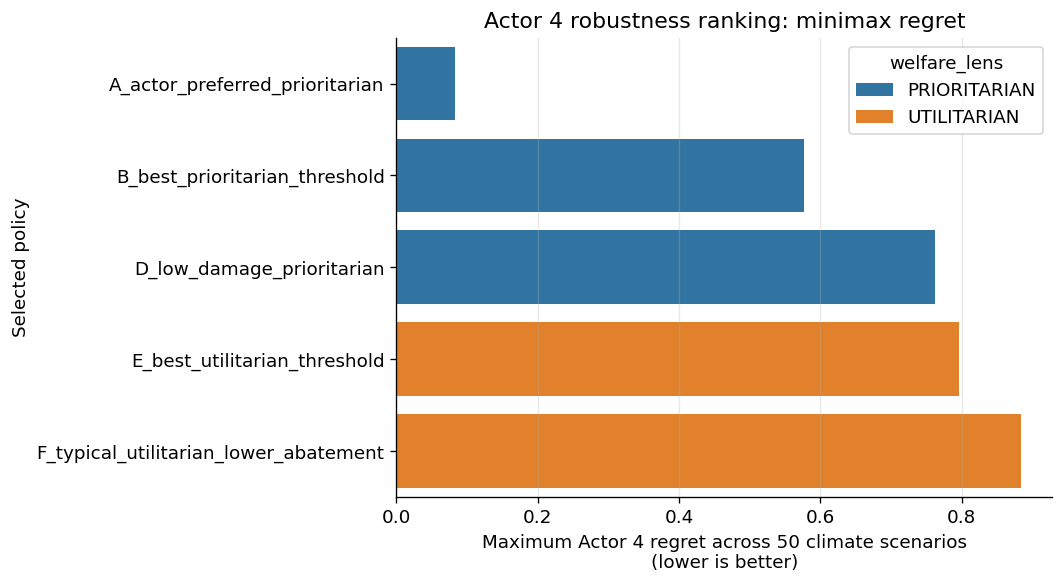

Saved → C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots\a08_actor4_minimax_regret_ranking.png


In [30]:
# ── Plot: Actor 4 minimax regret ranking ─────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(9, 5))

plot_df = combined.sort_values("max_actor4_regret").copy()

sns.barplot(
    data=plot_df,
    x="max_actor4_regret",
    y="selection_label",
    hue="welfare_lens",
    dodge=False
)

plt.title("Actor 4 robustness ranking: minimax regret")
plt.xlabel("Maximum Actor 4 regret across 50 climate scenarios\n(lower is better)")
plt.ylabel("Selected policy")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

out_path = os.path.join(
    r"C:\Users\jobm3\Downloads\Final_Assignment_ModelBased\plots",
    "a08_actor4_minimax_regret_ranking.png"
)

plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → {out_path}")